In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv('c:/data/creditcard/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


C:\Users\Admin\AppData\Local\Temp\ipykernel_10808\78659256.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=colors)


Text(0.5, 1.0, '분류\n (0:정상거래 || 1:비정상거래)')

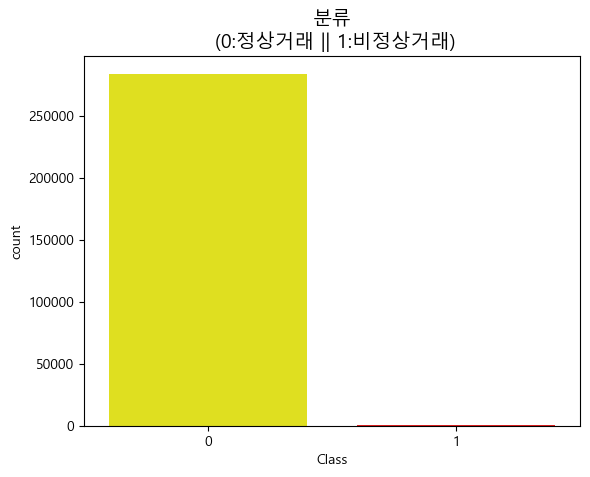

In [31]:
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname="C:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family=font_name)
colors = ['yellow','red']
sns.countplot(x='Class', data=df, palette=colors)
plt.title('분류\n (0:정상거래 || 1:비정상거래)', fontsize=14)


In [32]:
print('비정상거래')
print(df.Amount[df.Class == 1].describe())
print()
print('정상거래')
print(df.Amount[df.Class == 0].describe())

비정상거래
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

정상거래
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [33]:
train_cols = df.columns[1:29]
print(train_cols)
X = df[train_cols]
y = df['Amount']
print(X.head())
print(y.head())

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28'],
      dtype='object')
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V19       V20       V21       V22  \
0  0.098698  0.363787  0.090794  ...  0.403993  0.251412 -0.018307  0.277838   
1  0.085102 -0.255425 -0.166974  ... -0.145783 -0.069083 -0.225775 -0.638672   
2  0.247676 -1.514654  0.207643  ... -2.261857  0.524980  0.247998  0.771679  

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [35]:
import statsmodels.api as sm
model = sm.OLS(y_train, X_train)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Amount   R-squared (uncentered):                   0.814
Model:                            OLS   Adj. R-squared (uncentered):              0.814
Method:                 Least Squares   F-statistic:                          3.562e+04
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        17:00:41   Log-Likelihood:                     -1.4021e+06
No. Observations:              227845   AIC:                                  2.804e+06
Df Residuals:                  227817   BIC:                                  2.805e+06
Df Model:                          28                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
V1           -29.0712      0.122   -238.550      0.000     -29.310     -28.832
V2           -80.7410      0.144   -559.103      0.000     -81.024     -80.458
V3           -34.9901      0.157   -222.699      0.000     -35.298     -34.682
V4            17.6348      0.169    104.571      0.000      17.304      17.965
V5           -70.4015      0.172   -408.924      0.000     -70.739     -70.064
V6            40.9600      0.179    229.221      0.000      40.610      41.310
V7            80.8727      0.192    420.793      0.000      80.496      81.249
V8           -21.7477      0.201   -108.455      0.000     -22.141     -21.355
V9            -9.8589      0.217    -45.371      0.000     -10.285      -9.433
V10          -23.5126      0.219   -107.411      0.000     -23.942     -23.084
V11           -0.0321      0.234     -0.137      0.891      -0.490       0.426
V12           -2.4423      0.239    -10.234      0.000      -2.910      -1.975
V13            1.4716      0.239      6.145      0.000       1.002       1.941
V14            8.6866      0.249     34.853      0.000       8.198       9.175
V15           -0.7654      0.260     -2.940      0.003      -1.276      -0.255
V16           -0.9587      0.273     -3.516      0.000      -1.493      -0.424
V17            1.7505      0.280      6.248      0.000       1.201       2.300
V18           10.5612      0.284     37.148      0.000      10.004      11.118
V19          -17.2280      0.293    -58.781      0.000     -17.802     -16.654
V20          109.1117      0.311    350.781      0.000     108.502     109.721
V21           36.1316      0.328    110.291      0.000      35.490      36.774
V22          -22.3385      0.329    -67.881      0.000     -22.983     -21.693
V23          -45.9348      0.387   -118.681      0.000     -46.693     -45.176
V24            2.1648      0.394      5.496      0.000       1.393       2.937
V25          -22.7256      0.459    -49.542      0.000     -23.625     -21.827
V26           -1.2704      0.494     -2.571      0.010      -2.239      -0.302
V27           19.8272      0.588     33.694      0.000      18.674      20.981
V28            7.1256      0.712     10.011      0.000       5.731       8.521
==============================================================================
Omnibus:                   391012.898   Durbin-Watson:                   0.796
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      13742252161.963
Skew:                         -10.605   Prob(JB):                         0.00
Kurtosis:                    1205.949   Cond. No.                         5.84
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) sin

In [36]:
from sklearn.metrics import r2_score
pred = result.predict(X_test)
r2_score(y_test, pred)

0.8000119299914441

In [37]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train, y_train)
print('학습용:',model.score(X_train, y_train))
print('검증용:',model.score(X_test, y_test))

학습용: 0.9166679569637542
검증용: 0.9202403809857431
